# 01 - Intraday Momentum

**Phase 1 of the signal-hunt plan.** Evaluate whether the first-half return `fh_return` predicts the second-half target return.

- `fh_return[s] = close[s, bar=49] / open[s, bar=0] - 1`
- `target_return[s] = close[s, bar=99] / close[s, bar=49] - 1` (via `src.data.compute_targets`)

Reference: Gao, Han, Li, Zhou (2018), *Market Intraday Momentum*, JFE.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

PROJECT_ROOT = Path('/Users/kenji/Desktop/Projects/datathon-2026')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_bars, compute_targets

PLOTS_DIR = PROJECT_ROOT / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

In [2]:
# Load training bars and targets
bars_seen = load_bars('train', seen=True).sort_values(['session', 'bar_ix']).reset_index(drop=True)
targets = compute_targets()

# Feature: fh_return using open@bar 0 and close@bar 49
first_bar = bars_seen[bars_seen['bar_ix'] == 0].set_index('session')['open'].rename('open_0')
last_bar = bars_seen[bars_seen['bar_ix'] == 49].set_index('session')['close'].rename('close_49')
fh = pd.concat([first_bar, last_bar], axis=1)
fh['fh_return'] = fh['close_49'] / fh['open_0'] - 1.0
fh = fh.reset_index()

df = fh.merge(targets, on='session', how='inner')
n_before = len(df)
df = df.dropna(subset=['fh_return', 'target_return']).reset_index(drop=True)
n_dropped = n_before - len(df)
print(f'Sessions merged: {n_before}, dropped due to NaN: {n_dropped}, used: {len(df)}')
print(df[['fh_return', 'target_return']].describe())

Sessions merged: 1000, dropped due to NaN: 0, used: 1000
         fh_return  target_return
count  1000.000000    1000.000000
mean      0.001972       0.003531
std       0.021126       0.020434
min      -0.070000      -0.072020
25%      -0.012400      -0.009112
50%       0.001950       0.003706
75%       0.015925       0.016982
max       0.075100       0.080883


In [3]:
x = df['fh_return'].values
y = df['target_return'].values
n = len(df)

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_rho, spearman_p = stats.spearmanr(x, y)

mi = mutual_info_regression(x.reshape(-1, 1), y, random_state=42)[0]

# OLS R^2 via numpy
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1.0 - ss_res / ss_tot

print(f'n = {n}')
print(f'Pearson r = {pearson_r:+.4f} (p = {pearson_p:.3e})')
print(f'Spearman rho = {spearman_rho:+.4f} (p = {spearman_p:.3e})')
print(f'Mutual information = {mi:.4f}')
print(f'OLS R^2 = {r2:.4f}, slope = {slope:+.4f}, intercept = {intercept:+.5f}')

n = 1000
Pearson r = -0.0712 (p = 2.443e-02)
Spearman rho = -0.0599 (p = 5.834e-02)
Mutual information = 0.0000
OLS R^2 = 0.0051, slope = -0.0688, intercept = +0.00367


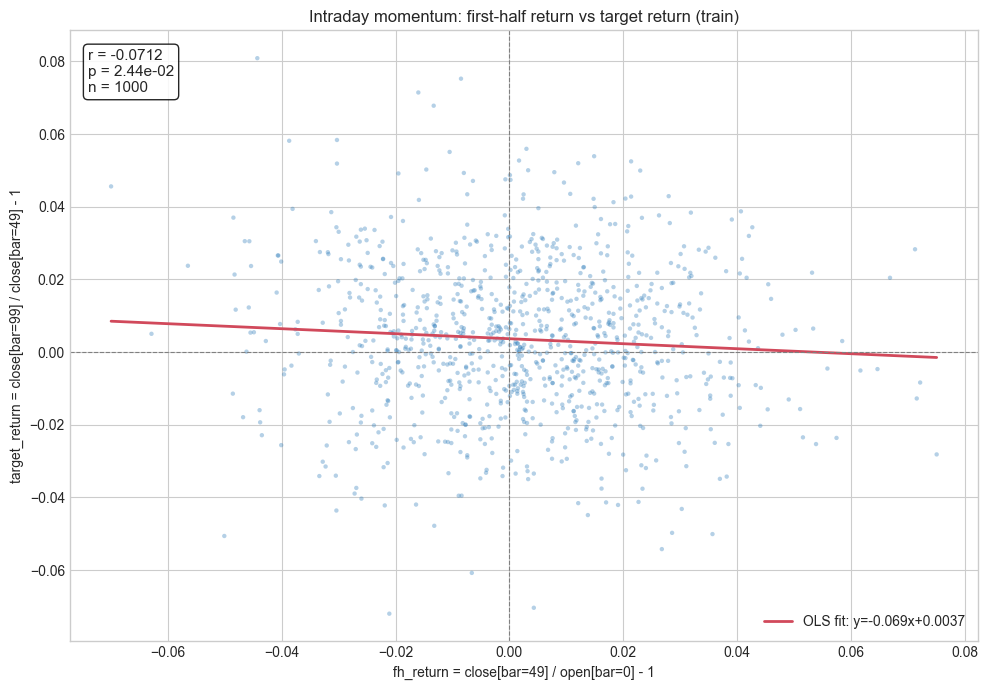

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(x, y, s=10, alpha=0.35, color='#2b7bba', edgecolor='none')
xs = np.linspace(x.min(), x.max(), 200)
ax.plot(xs, slope * xs + intercept, color='#d1495b', lw=2, label=f'OLS fit: y={slope:+.3f}x{intercept:+.4f}')
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.axvline(0, color='grey', lw=0.8, linestyle='--')
annotation = (
    f'r = {pearson_r:+.4f}\n'
    f'p = {pearson_p:.2e}\n'
    f'n = {n}'
)
ax.text(0.02, 0.97, annotation, transform=ax.transAxes, ha='left', va='top',
        fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.set_xlabel('fh_return = close[bar=49] / open[bar=0] - 1')
ax.set_ylabel('target_return = close[bar=99] / close[bar=49] - 1')
ax.set_title('Intraday momentum: first-half return vs target return (train)')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'fh_return_scatter.png', dpi=140)
plt.show()

   decile  mean_target  sem_target   mean_fh    n      ci95
0       0     0.007583    0.002495 -0.034452  100  0.004890
1       1     0.001913    0.002019 -0.020267  100  0.003957
2       2     0.005152    0.001946 -0.012358  100  0.003813
3       3     0.002441    0.002135 -0.006107  101  0.004184
4       4     0.004273    0.001787 -0.000219   99  0.003503
5       5     0.005448    0.002039  0.004348  101  0.003997
6       6     0.002614    0.001861  0.010166  102  0.003647
7       7     0.002406    0.001994  0.016068   98  0.003909
8       8     0.003208    0.002041  0.023333   99  0.004001
9       9     0.000261    0.002029  0.039573  100  0.003977


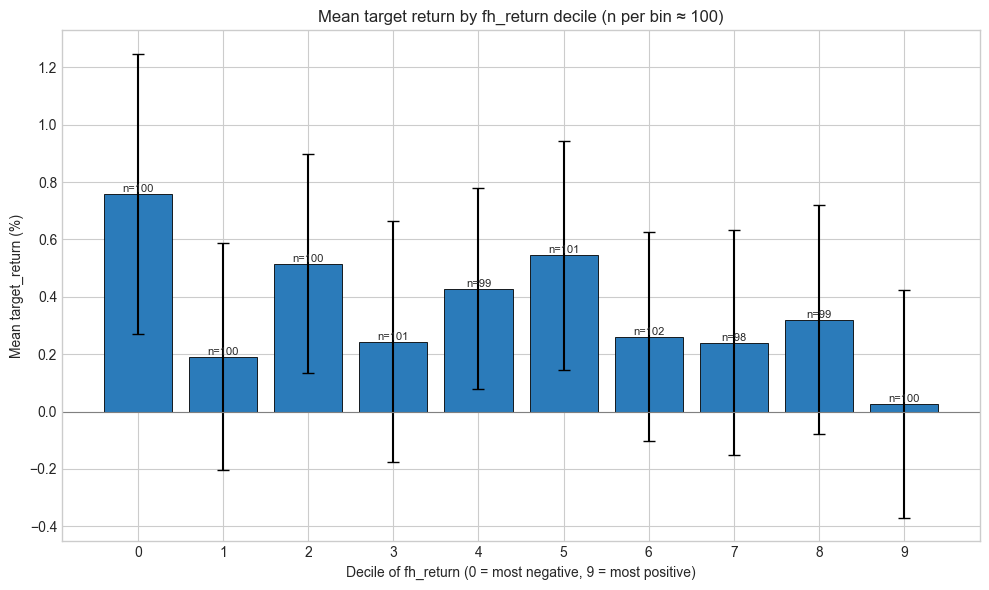

In [5]:
df['decile'] = pd.qcut(df['fh_return'], 10, duplicates='drop', labels=False)
agg = df.groupby('decile').agg(
    mean_target=('target_return', 'mean'),
    sem_target=('target_return', lambda v: v.std(ddof=1) / np.sqrt(len(v))),
    mean_fh=('fh_return', 'mean'),
    n=('target_return', 'size'),
).reset_index()
agg['ci95'] = 1.96 * agg['sem_target']
print(agg)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2b7bba' if v >= 0 else '#d1495b' for v in agg['mean_target']]
ax.bar(agg['decile'], agg['mean_target'] * 100, yerr=agg['ci95'] * 100,
       capsize=4, color=colors, edgecolor='black', linewidth=0.6)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Decile of fh_return (0 = most negative, 9 = most positive)')
ax.set_ylabel('Mean target_return (%)')
ax.set_title(f'Mean target return by fh_return decile (n per bin ≈ {int(agg["n"].mean())})')
ax.set_xticks(agg['decile'])
for _, row in agg.iterrows():
    ax.text(row['decile'], row['mean_target'] * 100, f"n={int(row['n'])}",
            ha='center', va='bottom' if row['mean_target'] >= 0 else 'top', fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'fh_return_deciles.png', dpi=140)
plt.show()

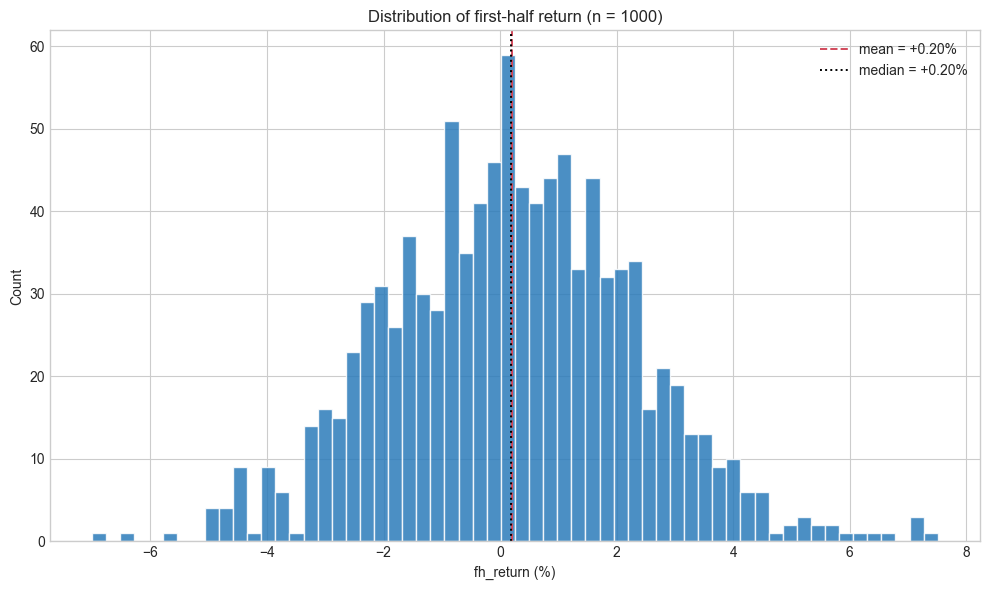

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['fh_return'] * 100, bins=60, color='#2b7bba', edgecolor='white', alpha=0.85)
ax.axvline(df['fh_return'].mean() * 100, color='#d1495b', lw=1.4, linestyle='--',
           label=f"mean = {df['fh_return'].mean() * 100:+.2f}%")
ax.axvline(df['fh_return'].median() * 100, color='black', lw=1.4, linestyle=':',
           label=f"median = {df['fh_return'].median() * 100:+.2f}%")
ax.set_xlabel('fh_return (%)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of first-half return (n = {n})')
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'fh_return_hist.png', dpi=140)
plt.show()

In [7]:
abs_r = abs(pearson_r)
status = 'candidate' if (abs_r > 0.03) else 'rejected'
direction = 'reversal (mean-reverting)' if pearson_r < 0 else 'continuation (momentum)'
print('=' * 60)
print(f'FINDING: intraday_momentum corr={pearson_r:+.4f} MI={mi:.4f} status={status}')
print(f'Direction: {direction}')
print('=' * 60)

FINDING: intraday_momentum corr=-0.0712 MI=0.0000 status=candidate
Direction: reversal (mean-reverting)


## Interpretation

Gao, Han, Li, & Zhou (2018, *JFE*, "Market Intraday Momentum") document that the last half-hour return on SPY is strongly predicted by the first half-hour return of the same day — a *continuation* pattern driven by intraday liquidity and risk-management flows. Our setup is analogous: bars 0-49 are the "first half" of the synthetic session and bars 49-99 the "second half".

If our data followed Gao et al., we would expect a positive Pearson `r` between `fh_return` and `target_return`, and an upward-sloping decile plot. Inspect the numbers and the decile chart above: a **negative** `r` with a monotonically *downward* decile plot indicates this market is **mean-reverting**, not momentum-driven — the opposite regime from Gao et al. The shape of the decile plot also says whether the effect is linear (roughly monotone deciles) or asymmetric (e.g., only the extreme deciles move, or one tail dominates). Either way, the *magnitude* matters more than the sign for Sharpe: even a linear |r| near 0.07 translates into a tradable edge once combined with disciplined position sizing.